In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

In [2]:
nvda_dataset = pd.read_csv('nvdia - Transcrição de Tabela Financeira de Ações.csv')
nvda_dataset.head()

,Data,Abrir,Alto,Baixo,Fechar,Adj Fechar,Volume
0,9 de março de 2026,"176,83","182,91","175,56","182,65","182,65",176.547.500
1,6 de março de 2026,"179,84","182,76","176,82","177,82","177,82",189.021.900
2,5 de março de 2026,"181,17","184,06","177,88","183,34","183,34",198.779.700
3,4 de março de 2026,"180,44","184,7","180,06","183,04","183,04",177.731.200
4,3 de março de 2026,"178,49","180,9","176,92","180,05","180,05",178.099.400


In [3]:
nvda_dataset.shape

(255, 7)

In [4]:
nvda_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Data        255 non-null    object
 1   Abrir       251 non-null    object
 2   Alto        251 non-null    object
 3   Baixo       255 non-null    object
 4   Fechar      251 non-null    object
 5   Adj Fechar  251 non-null    object
 6   Volume      251 non-null    object
dtypes: object(7)
memory usage: 14.1+ KB


In [5]:
nvda_dataset.isnull().sum().sort_values(ascending=False)

Abrir         4
Alto          4
Fechar        4
Adj Fechar    4
Volume        4
Data          0
Baixo         0
dtype: int64

In [6]:
nvda_dataset = nvda_dataset.dropna()

In [7]:
nvda_dataset.isnull().sum().sort_values(ascending=False)

Data          0
Abrir         0
Alto          0
Baixo         0
Fechar        0
Adj Fechar    0
Volume        0
dtype: int64

In [8]:
nvda_dataset.columns

Index(['Data', 'Abrir', 'Alto', 'Baixo', 'Fechar', 'Adj Fechar', 'Volume'], dtype='object')

In [9]:
nvda_dataset.rename(columns={
    'Data': 'Date',
    'Abrir': 'Open',
    'Alto': 'High',
    'Baixo': 'Low',
    'Fechar': 'Close',
    'Adj Fechar': 'Adj Close'
}, inplace=True)

nvda_dataset.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,9 de março de 2026,"176,83","182,91","175,56","182,65","182,65",176.547.500
1,6 de março de 2026,"179,84","182,76","176,82","177,82","177,82",189.021.900
2,5 de março de 2026,"181,17","184,06","177,88","183,34","183,34",198.779.700
3,4 de março de 2026,"180,44","184,7","180,06","183,04","183,04",177.731.200
4,3 de março de 2026,"178,49","180,9","176,92","180,05","180,05",178.099.400


In [10]:
nvda_dataset['Date'] = nvda_dataset['Date'].replace({
    'janeiro': '01', 'fevereiro': '02', 'março': '03',
    'abril': '04', 'maio': '05', 'junho': '06',
    'julho': '07', 'agosto': '08', 'setembro': '09',
    'outubro': '10', 'novembro': '11', 'dezembro': '12'
}, regex=True)

nvda_dataset['Date'] = nvda_dataset['Date'].str.replace('de', '')
nvda_dataset['Date'] = nvda_dataset['Date'].str.replace('º', '', regex=False)
nvda_dataset['Date'] = pd.to_datetime(nvda_dataset['Date'], dayfirst=True)

In [11]:
print(nvda_dataset['Date'].dtype)

datetime64[ns]


In [12]:
nvda_dataset = nvda_dataset.set_index('Date')

In [13]:
nvda_dataset.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [14]:
colunas = ['Open', 'High', 'Low', 'Close', 'Adj Close']

for col in colunas:
    nvda_dataset[col] = (
        nvda_dataset[col]
        .astype(str)
        .str.replace(',', '.')
        .astype(float)
    )

nvda_dataset['Volume'] = (
nvda_dataset['Volume']
    .astype(str)
    .str.replace('.', '')
    .astype(int)
)

In [15]:
nvda_dataset[colunas] = nvda_dataset[colunas].apply(pd.to_numeric)

In [16]:
nvda_dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2026-03-09 to 2025-03-10
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       251 non-null    float64
 1   High       251 non-null    float64
 2   Low        251 non-null    float64
 3   Close      251 non-null    float64
 4   Adj Close  251 non-null    float64
 5   Volume     251 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 13.7 KB


In [17]:
nvda_dataset.describe()

,Open,High,Low,Close,Adj Close,Volume
count,251.000000,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,163.578048,165.910438,161.047012,163.610120,163.597251,2.027177e+08
std,29.774089,29.658082,29.461786,29.375445,29.381247,7.542727e+07
min,87.460000,99.440000,86.820000,94.310000,94.290000,6.552850e+07
25%,142.365000,143.790000,141.180000,141.945000,141.920000,1.541956e+08
50%,176.690000,179.780000,174.900000,177.720000,177.720000,1.831337e+08
75%,184.760000,187.190000,182.045000,184.915000,184.915000,2.287097e+08
max,208.080000,212.190000,205.560000,207.040000,207.030000,6.129183e+08


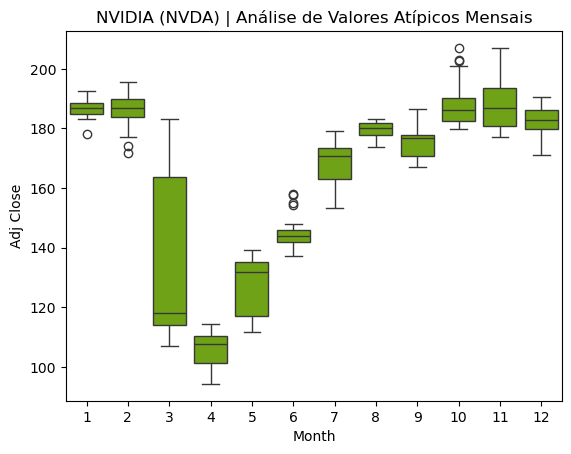

In [18]:
# Existem meses específicos onde o preço oscila mais radicalmente?

nvda_dataset['Month'] = nvda_dataset.index.month

sns.boxplot(data=nvda_dataset, x='Month' , y='Adj Close', color='#76B900')
plt.title('NVIDIA (NVDA) | Análise de Valores Atípicos Mensais');

In [19]:
nvda_dataset.groupby(['Month']).describe()['Adj Close']

,count,mean,std,min,25%,50%,75%,max
Month,,,,,,,,
1,20.0,186.722000,3.293193,178.07,184.9200,186.760,188.6025,192.51
2,19.0,185.711579,6.196736,171.88,183.8500,186.940,189.9300,195.56
3,22.0,133.264545,30.569410,106.95,114.1575,118.095,163.7775,183.34
4,21.0,105.454286,6.012581,94.29,101.4700,107.550,110.4000,114.31
5,21.0,127.291429,9.543740,111.59,117.0400,131.780,135.1100,139.16
6,20.0,145.672000,5.889249,137.36,141.9350,144.015,146.0650,157.97
7,22.0,168.044091,7.354784,153.28,163.1575,170.720,173.3550,179.25
8,21.0,179.394286,2.979947,173.70,177.9700,180.150,181.7500,183.14
9,21.0,175.730476,5.019990,167.00,170.7600,176.960,177.8100,186.57


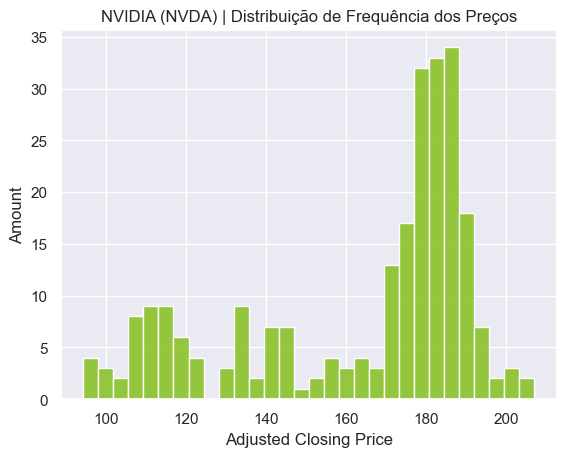

In [20]:
# Qual a distribuição dos preços da ação?

sns.set_theme(style="darkgrid")
sns.histplot(nvda_dataset['Adj Close'], bins=30, color="#76B900")
plt.title('NVIDIA (NVDA) | Distribuição de Frequência dos Preços')
plt.xlabel('Adjusted Closing Price')
plt.ylabel('Amount')
plt.show()

In [21]:
# Como o preço da ação evoluiu ao longo do tempo?

fig = px.line(nvda_dataset, y='Adj Close', color_discrete_sequence=['#76B900'])
fig.update_layout(
    width = 1200,
    height = 500,
    title = {'text': 'NVIDIA (NVDA) | Evolução Histórica de Preços', 'font': {'size': 20}
             },
             xaxis_title = 'Período de Coração',
             yaxis_title = 'Valor da Ação (USD $)',
)
fig.update_traces(line=dict(width=2))
fig.show()

In [27]:
# Qual a tendência de longo prazo da ação?

avarange_moving = nvda_dataset['Adj Close'].rolling(5).mean()
avarange_trend = nvda_dataset['Adj Close'].rolling(30).mean()

figMT = go.Figure()

figMT.add_trace(
    go.Scatter(
        x = nvda_dataset.index,
        y = nvda_dataset.Close,
        mode = 'lines',
        name = 'Fechamento',
        marker_color = "#000DFF",
    )
)
figMT.add_trace(
    go.Scatter(
        x = nvda_dataset.index,
        y = avarange_moving,
        mode = 'lines',
        name = 'Média Móvel',
        marker_color = "#FF0000",
        opacity = 0.8
    )
)
figMT.add_trace(
    go.Scatter(
        x = nvda_dataset.index,
        y = avarange_trend,
        mode = 'lines',
        name = 'Tendência',
        marker_color = '#76B900',
    )
)
figMT.update_layout(
    width=1000,
    height=500,
    title={
        'text': 'NVIDIA (NVDA) | Análise de Médias e Tendência',
        'font': {'size': 20}
    },
    xaxis_title='Período de Cotação',
    yaxis_title='Valor da Ação (USD $)',
    hovermode='x unified'
)

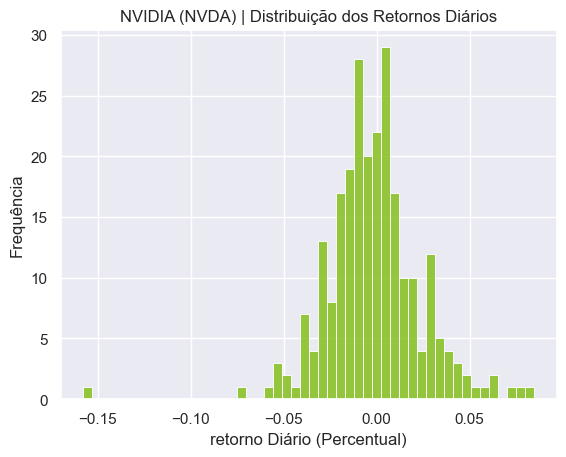

In [23]:
# Qual é o retorno diário da ação?

nvda_dataset['Daily Return'] = nvda_dataset['Adj Close'].pct_change()

sns.histplot(nvda_dataset['Daily Return'],
              bins = 50, color = '#76B900')
plt.title('NVIDIA (NVDA) | Distribuição dos Retornos Diários')
plt.xlabel('retorno Diário (Percentual)')
plt.ylabel('Frequência')
plt.show()

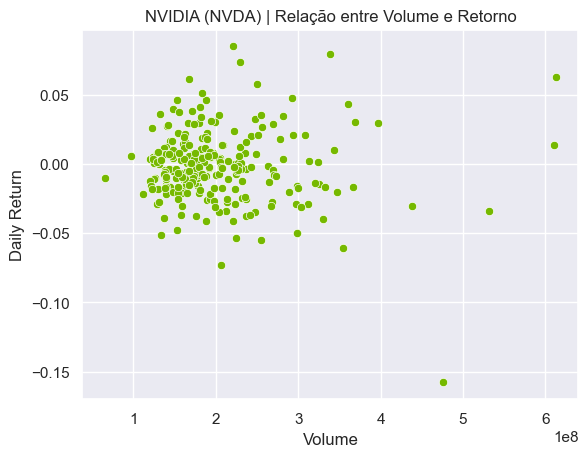

In [24]:
# Relação Volume e preço?

sns.set_theme(style="darkgrid")
sns.scatterplot(
    x = nvda_dataset['Volume'],
    y = nvda_dataset['Daily Return'],
    color = '#76B900'
)

plt.title('NVIDIA (NVDA) | Relação entre Volume e Retorno')
plt.xlabel('Volume')
plt.ylabel('Daily Return')
plt.show()


In [25]:
graphic = go.Figure(
    data = [
        go.Candlestick(
            x = nvda_dataset.index,
            open = nvda_dataset['Open'],
            high = nvda_dataset['High'],
            low = nvda_dataset['Low'],
            close = nvda_dataset['Adj Close'],
            increasing_line_color='#26a69a', # Verde Esmeralda
            decreasing_line_color='#ef5350'  # Vermelho Coral
        )
    ]
)
graphic.update_layout(
    template='plotly_dark',
    xaxis_rangeslider_visible=False,
    title='NVIDIA (NVDA) | Monitoramento de Preços OHLC',
    font=dict(size=15),
    xaxis_title='Período de cotação',
    yaxis_title='Valor da ação (USD $)',
    width=1200,
    height=600,
)
graphic.show()

In [26]:

# Se eu tivesse comprado NVIDIA no pior momento do ano, quanto eu estaria perdendo hoje?
yearly_max = nvda_dataset['Adj Close'].max()

current_price = nvda_dataset['Adj Close'].iloc[-1]

drawdown = (current_price - yearly_max) / yearly_max * 100

print(f"Maior preço do ano: ${yearly_max:.2f}")
print(f"Preço atual: ${current_price:.2f}")
print(f"Drawdown atual: {drawdown:.2f}%")

Maior preço do ano: $207.03
Preço atual: $106.95
Drawdown atual: -48.34%
